In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [4]:
from variable_print import p,ps,pst

# REINFORCE Algorithm 구현

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import matplotlib.pyplot as plt
import time
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## Environment : CartPole 생성

In [6]:
import gymnasium as gym
env = gym.make("CartPole-v1", render_mode="rgb_array")
print(gym.__version__)  #0.25.2
print("="*10)
print('State space: ', env.observation_space)
print('Action space: ', env.action_space)
print("="*10)
s_dim = env.observation_space.shape[0]
a_dim = env.action_space.n
print(f"State dimension: {s_dim}")
print(f"Action dimension: {a_dim}")

1.2.0
State space:  Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space:  Discrete(2)
State dimension: 4
Action dimension: 2


## Neural Network 만들기  

In [7]:
"""## Policy Network 정의 (PyTorch)"""
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.dropout = nn.Dropout(p=0.6)
        self.fc2 = nn.Linear(128, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.dropout(x)
        x = F.relu(x)
        # 행동 확률을 출력하기 위해 Softmax 적용
        action_probs = F.softmax(self.fc2(x), dim=-1)
        return action_probs

## REINFORCE Agent 만들기  


In [8]:
# 학습 관련
learning_rate = 0.01
gamma = 0.99
n_episode = 200

"""## REINFORCE Agent 클래스 정의"""

class ReinforceAgent:
    def __init__(self, env):
        self.env = env
        self.state_size = env.observation_space.shape[0]
        self.action_size = env.action_space.n

        # 정책 네트워크와 옵티마이저 생성
        self.policy_network = PolicyNetwork(self.state_size, self.action_size)
        self.optimizer = optim.Adam(self.policy_network.parameters(), lr=learning_rate)

        # 한 에피소드의 데이터를 저장할 리스트
        self.rewards = []
        self.log_probs = []

    def get_action(self, state):
        """정책 네트워크를 기반으로 행동을 샘플링하고 로그 확률을 저장"""
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        action_probs = self.policy_network(state_tensor)

        # 확률 분포에서 행동 샘플링
        dist = Categorical(action_probs)
        action = dist.sample()

        # 나중에 loss 계산을 위해 선택된 행동의 로그 확률 저장
        self.log_probs.append(dist.log_prob(action))
        return action.item()

    def update_policy(self):
        """에피소드가 끝난 후 정책 네트워크를 업데이트"""
        discounted_rewards = []
        R = 0
        # 에피소드의 마지막 보상부터 역순으로 할인된 보상(Return) 계산
        for r in reversed(self.rewards):
            R = r + gamma * R
            discounted_rewards.insert(0, R)

        # 텐서로 변환 및 정규화 (학습 안정성 향상)
        discounted_rewards = torch.FloatTensor(discounted_rewards)
        discounted_rewards = (discounted_rewards - discounted_rewards.mean()) / (discounted_rewards.std() + 1e-9)

        policy_loss = []
        for log_prob, R in zip(self.log_probs, discounted_rewards):
            # REINFORCE 손실 함수: -log(pi(a|s)) * G_t
            policy_loss.append(-log_prob * R)

        # 옵티마이저 업데이트
        self.optimizer.zero_grad()
        policy_loss = torch.cat(policy_loss).sum()
        policy_loss.backward()
        self.optimizer.step()

        # 다음 에피소드를 위해 데이터 초기화
        self.rewards = []
        self.log_probs = []

        return policy_loss.item()

    def save_model(self, path):
        torch.save(self.policy_network.state_dict(), path)
#        print(f"모델이 {path}에 저장되었습니다.")

    def load_model(self, path):
        self.policy_network.load_state_dict(torch.load(path))
        self.policy_network.eval()
        print(f"모델을 {path}에서 불러왔습니다.")



## Training

In [9]:
model_path = path+"models/DRL/reinforce_cartpole_best.pth"

In [10]:
%%time
agent = ReinforceAgent(env)
scores = []
losses = []
max_score = -np.inf

print("학습을 시작합니다...")
for e in range(1, n_episode + 1):
    state, info = env.reset()
    done = False
    score = 0

    while not done:
        action = agent.get_action(state)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        agent.rewards.append(reward)
        state = next_state
        score += reward

    # 에피소드가 끝나면 정책 업데이트
    loss = agent.update_policy()
    losses.append(loss)
    scores.append(score)

    mean_score = np.mean(scores[-10:])
    print(f"Episode {e}, Score: {score}, Avg Score: {mean_score:.2f}, Loss: {loss:.2f}")

    if mean_score > max_score and len(scores) > 10:
        max_score = mean_score
        agent.save_model(model_path)
        print(f"  model saved:{max_score:.2f}")
    if max_score > 300 : break
#env.close()
print("학습 종료!")

# Wall time: 34.9 s

학습을 시작합니다...
Episode 1, Score: 58.0, Avg Score: 58.00, Loss: 0.91
Episode 2, Score: 25.0, Avg Score: 41.50, Loss: 0.50
Episode 3, Score: 26.0, Avg Score: 36.33, Loss: -0.86
Episode 4, Score: 14.0, Avg Score: 30.75, Loss: 1.13
Episode 5, Score: 27.0, Avg Score: 30.00, Loss: -1.32
Episode 6, Score: 22.0, Avg Score: 28.67, Loss: 0.87
Episode 7, Score: 14.0, Avg Score: 26.57, Loss: 1.12
Episode 8, Score: 24.0, Avg Score: 26.25, Loss: 1.89
Episode 9, Score: 20.0, Avg Score: 25.56, Loss: -1.33
Episode 10, Score: 77.0, Avg Score: 30.70, Loss: 4.04
Episode 11, Score: 25.0, Avg Score: 27.40, Loss: -2.53
  model saved:27.40
Episode 12, Score: 46.0, Avg Score: 29.50, Loss: -1.00
  model saved:29.50
Episode 13, Score: 51.0, Avg Score: 32.00, Loss: 1.28
  model saved:32.00
Episode 14, Score: 36.0, Avg Score: 34.20, Loss: 0.42
  model saved:34.20
Episode 15, Score: 22.0, Avg Score: 33.70, Loss: 0.53
Episode 16, Score: 20.0, Avg Score: 33.50, Loss: -0.87
Episode 17, Score: 28.0, Avg Score: 34.90, Los

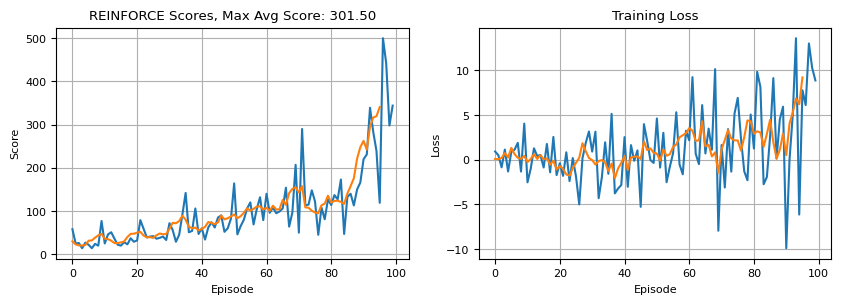

In [11]:
"""## 학습 결과 시각화"""
def plot_moving_avg(data, window_size):
    if not data: return
    moving_avg = np.convolve(data, np.ones(window_size)/window_size, mode='valid')
    plt.plot(moving_avg)

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(scores)
plot_moving_avg(scores,5)
plt.title(f'REINFORCE Scores, Max Avg Score: {max_score:.2f}')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(losses)
plot_moving_avg(losses,5)
plt.title('Training Loss')
plt.xlabel('Episode')
plt.ylabel('Loss')
plt.grid()
plt.show()

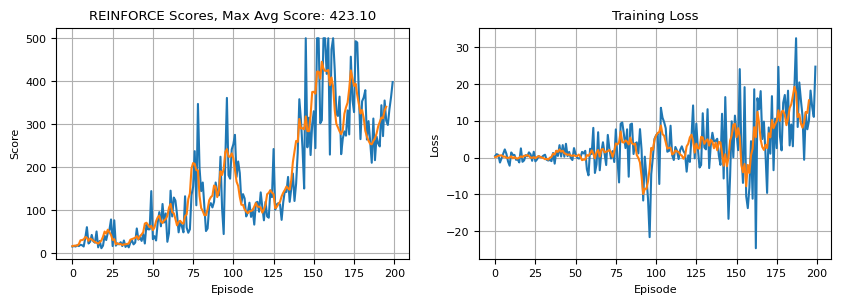

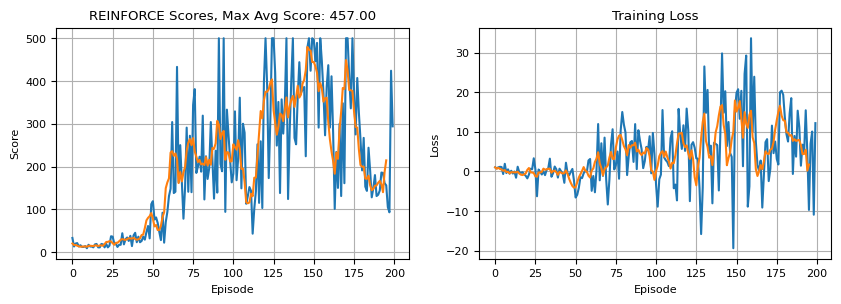

## Evaluation

In [ ]:
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [ ]:
from pyvirtualdisplay import Display
virtual_display = Display(visible=0, size=(400, 300))
virtual_display.start()

In [ ]:
from render import  show_video, wrap_env, render_as_image

In [ ]:
video_prefix = "pt_reinforce"
eval_env = wrap_env(env, path=path, name_prefix=video_prefix)

/usr/local/lib/python3.11/dist-packages/gym/wrappers/record_video.py:78: UserWarning: WARN: Overwriting existing videos at /content/gdrive/MyDrive/Colab Notebooks/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [ ]:
# 학습된 가중치를 불러올 새로운 에이전트 생성
agent_test = ReinforceAgent(env)
agent_test.load_model(model_path)

모델을 /content/gdrive/MyDrive/Colab Notebooks/models/DRL/reinforce_cartpole_best.pth에서 불러왔습니다.


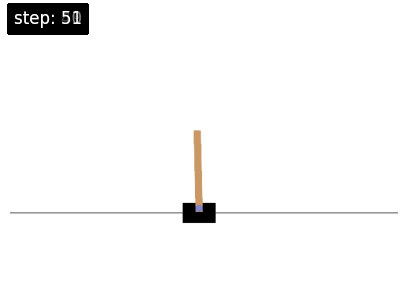

In [ ]:
state, info = eval_env.reset()
step_cnt = 0

while True:
    render_as_image(eval_env, step=step_cnt)
    # REINFORCE는 확률적으로 행동하므로 get_action을 그대로 사용
    action = agent_test.get_action(state)
    next_state, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated
    state = next_state

    if done or step_cnt > 50:
        break
    step_cnt += 1

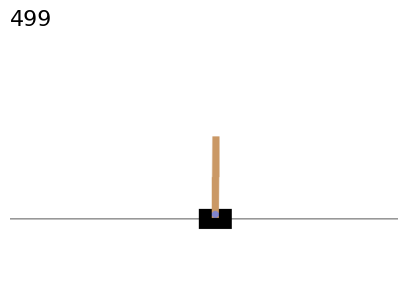

In [ ]:
show_video(path=path, name_prefix=video_prefix)

/content/gdrive/MyDrive/Colab Notebooks/video/pt_reinforce-cartpole-episode-0.mp4


In [ ]:
show_video(path=path,name_prefix='REINFORCE')

/content/gdrive/MyDrive/Colab Notebooks/video/REINFORCE-episode-0.mp4
